# Delivery design - the Portfolio Drift Monitor as something someone acts on

**Stage 12.** Companion to `src/reporting.py` and `docs/reporting.md`.

Eleven stages produced a model. This one produces a **decision**, and the two are not the
same artifact. The work here is in three parts:

1. **Settle the bias question Stage 11 left open**, which turns out to have a different
   answer than Stage 11 expected.
2. **Find out which assumption the conclusion actually rests on**, by swinging each one
   and measuring, rather than by listing them all as equally important.
3. **Ship two artifacts for two readers**, because the principal is deciding whether to
   trust the model and Dana is deciding whether to send an email.

In [1]:
# --- run me first ---
from pathlib import Path
import os, sys
if Path.cwd().name == 'notebooks':
    os.chdir('..')
ROOT = Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
print('working from:', ROOT.name)

working from: project


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src import features as fe, modeling as md, evaluation as ev, reporting as rp
from src.utils import TARGET_WEIGHTS, AMBER_PP, RED_PP, read_df

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110

RAW, PROC = Path('data/raw'), Path('data/processed')
REPORTS = Path('reports'); IMG = REPORTS / 'images'
IMG.mkdir(parents=True, exist_ok=True)

HORIZON = 21
TARGET = f'y_absdrift_fwd_{HORIZON}'
SEED, N_BOOT, LEVEL = 111, 2000, 0.95

FUND_COLOR = {'VTI': '#1f4e79', 'VXUS': '#c77b30', 'BND': '#4a7c59'}
ORDER = rp.DISPLAY_ORDER

def savefig(fig, name):
    fig.savefig(IMG / name, dpi=300, bbox_inches='tight')
    print(f'saved reports/images/{name}')

print(f'seed {SEED} | {N_BOOT} resamples | level {LEVEL:.2f} | '
      f'amber {AMBER_PP:.0f}pp | red {RED_PP:.0f}pp')

seed 111 | 2000 resamples | level 0.95 | amber 3pp | red 5pp


## 1. The specifications on the table

Four candidates, all scored on the Stage 10a chronological split so the comparison is
between the specifications rather than between how each was run.

In [3]:
clean = sorted(PROC.glob('prices_clean_*.parquet'))
src_path = clean[-1] if clean else sorted(RAW.glob('api_yfinance_*.csv'))[-1]
prices = read_df(src_path) if str(src_path).endswith('parquet') else pd.read_csv(src_path)
prices['date'] = pd.to_datetime(prices['date'])

matrix = fe.build_feature_matrix(prices, TARGET_WEIGHTS, prices_raw=prices, horizon=HORIZON)

FULL = [c for c in fe.MODEL_FEATURES if c != 'ticker_BND']
FIVE = ['abs_drift', 'abs_drift_rel', 'drift_chg_1', 'drift_chg_5', 'drift_slope_21']

data = (matrix[['date', 'ticker'] + fe.MODEL_FEATURES + [TARGET]]
        .dropna().sort_values(['date', 'ticker']).reset_index(drop=True))
train, test, cut = md.chronological_split(data, test_frac=0.2)

def fit_resid(tr, te, feats):
    f = md.fit_ols(tr[feats].to_numpy(), tr[TARGET].to_numpy(), feats)
    return f, te[TARGET].to_numpy() - md.predict_ols(f['beta'], te[feats].to_numpy())

fit11, r11 = fit_resid(train, test, FULL)
fit5,  r5  = fit_resid(train, test, FIVE)

tr_s, feats_s = rp.fund_interactions(train, FULL, ['drift_slope_21'])
te_s, _       = rp.fund_interactions(test,  FULL, ['drift_slope_21'])
fitS, rS = fit_resid(tr_s, te_s, feats_s)

SEP = [c for c in FIVE if c != 'abs_drift_rel']
rE = np.zeros(len(test))
for t in ORDER:
    a, b = (train['ticker'] == t), (test['ticker'] == t).to_numpy()
    f = md.fit_ols(train.loc[a, SEP].to_numpy(), train.loc[a, TARGET].to_numpy(), SEP)
    rE[b] = test.loc[b, TARGET].to_numpy() - md.predict_ols(f['beta'], test.loc[b, SEP].to_numpy())

sweep = rp.specification_sweep({
    'pooled 11-param (Stage 10a)': {'resid': r11, 'k': 11},
    'pooled 6-param (5 features)': {'resid': r5,  'k': 6},
    'slope x fund interaction':    {'resid': rS,  'k': 13},
    'separate model per fund':     {'resid': rE,  'k': 15},
}, test['ticker'].to_numpy(), test[TARGET].to_numpy())
sweep.to_csv(PROC / 'report_specification_sweep.csv')

print(f'source {src_path.name} | cut {cut.date()} | train {len(train)} | '
      f"test {len(test)} over {test['date'].nunique()} dates")
print()
print(sweep.to_string())

source prices_clean_20260830-1204.parquet | cut 2026-06-01 | train 501 | test 126 over 42 dates

                              k     mae    rmse    bias  bias_VTI  bias_VXUS  bias_BND
spec                                                                                  
pooled 11-param (Stage 10a)  11  0.1915  0.2333  0.0951    0.2147    -0.0634    0.1340
pooled 6-param (5 features)   6  0.1759  0.2112  0.0802    0.0813     0.0091    0.1503
slope x fund interaction     13  0.1810  0.2243  0.0647    0.2277    -0.0564    0.0227
separate model per fund      15  0.2156  0.2668  0.0751    0.1857    -0.1436    0.1831


## 2. Stage 11's recommendation, and why it cannot be carried out

Stage 11 measured a systematic under-prediction for VTI and BND and recommended per-fund
interactions, noting the fund dummies already existed. Building them turned up two
independent rank failures, and both trace to one property of the Stage 09 feature set.

In [4]:
# The structural fact behind both failures.
recon = data['abs_drift'] / data['ticker'].map(TARGET_WEIGHTS)
print('max |abs_drift_rel - abs_drift / target_weight| = %.2e'
      % float((data['abs_drift_rel'] - recon).abs().max()))
print('abs_drift_rel IS abs_drift interacted with the fund, under another name.')
print()

try:
    rp.fund_interactions(train, FULL, ['abs_drift'])
except ValueError as e:
    print('pooled + explicit interaction ->', str(e).split(':')[0])
try:
    md.fit_ols(train.loc[train['ticker'] == 'VTI', FIVE].to_numpy(),
               train.loc[train['ticker'] == 'VTI', TARGET].to_numpy(), FIVE)
except ValueError:
    print('per-fund model with both columns -> rank deficient (inside one fund, '
          'abs_drift_rel is a constant multiple of abs_drift)')

max |abs_drift_rel - abs_drift / target_weight| = 1.78e-15
abs_drift_rel IS abs_drift interacted with the fund, under another name.

pooled + explicit interaction -> ['abs_drift'] cannot be interacted with the fund while 'abs_drift_rel' is in the model
per-fund model with both columns -> rank deficient (inside one fund, abs_drift_rel is a constant multiple of abs_drift)


In [5]:
# So where does the bias come from? Fit residuals first.
r11_train = train[TARGET].to_numpy() - md.predict_ols(fit11['beta'], train[FULL].to_numpy())
print('in-sample bias by fund, 11-param model')
for t in ORDER:
    m = (train['ticker'] == t).to_numpy()
    print(f'  {t:<5} {r11_train[m].mean():+.6f} pp')
print()
print('Zero to machine precision: the fund dummies force it. A per-fund term fitted on')
print('this window cannot see a bias that does not exist in this window.')
print()

shift = rp.regime_shift(train, test, TARGET)
shift.to_csv(PROC / 'report_regime_shift.csv')
print(shift.to_string())

in-sample bias by fund, 11-param model
  VTI   +0.000000 pp
  VXUS  +0.000000 pp
  BND   +0.000000 pp

Zero to machine precision: the fund dummies force it. A per-fund term fitted on
this window cannot see a bias that does not exist in this window.

        train_mean  test_mean   shift
ticker                               
BND         0.7350     1.5494  0.8144
VTI         0.4707     0.6030  0.1323
VXUS        0.9725     0.9463 -0.0262
ALL         0.7261     1.0329  0.3068


**The answer.** The bias is not misspecification, it is the world moving. Average
21-trading-day-ahead absolute drift rose from **0.726pp** in the training window to
**1.033pp** in the test window, a **+0.31pp** shift, and BND's own target rose **+0.81pp**.
Nothing fitted on the training window can anticipate that.

The specification sweep says the same thing from the other direction. Giving the model
more freedom makes it worse on both counts at once: separate per-fund models spend 15
parameters against roughly 24 independent observations, score **MAE 0.216** where the
6-parameter model scores **0.176**, and leave all three funds biased rather than two.

**So the correction is the smaller model plus a published offset**, and the offset is
labelled as a measured observation rather than a fitted parameter, because that is what it
is. `docs/evaluation.md` has been amended where it recommended otherwise.

## 3. Which assumption the conclusion rests on

The headline is **BND's 95% upper bound**: BND is the fund closest to amber, and the upper
bound rather than the point estimate is what would trigger action. Each assumption is
swung once, from its published value to its most defensible alternative.

saved reports/images/report_tornado.png


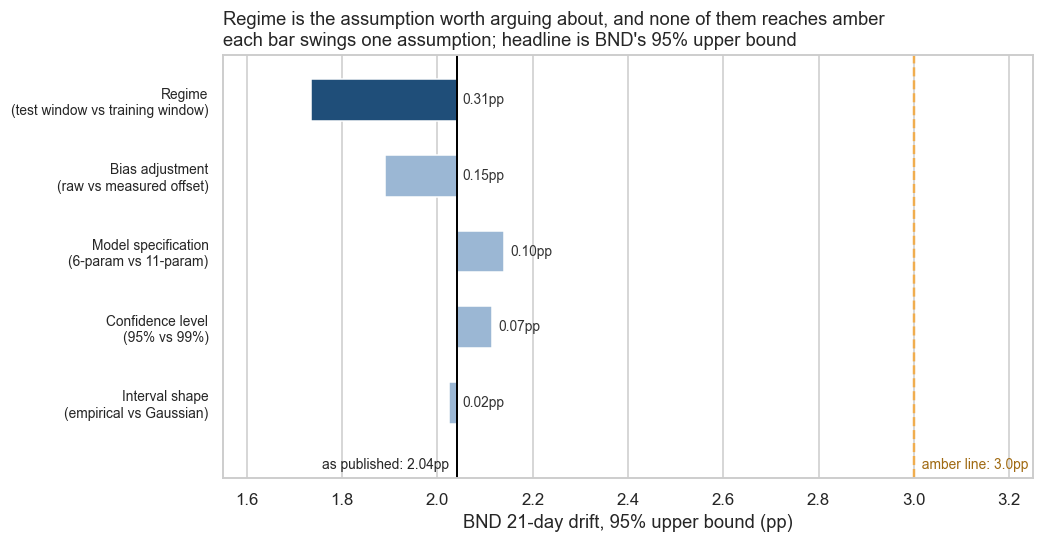


                                 scenario                                      assumption  bnd_upper_95_pp   delta  pct_change
                                 baseline test-window regime, 6-param, raw, empirical 95%           2.0409  0.0000      0.0000
  Regime (test window vs training window)                                       alternate           1.7341 -0.3068    -15.0310
 Bias adjustment (raw vs measured offset)                                       alternate           1.8906 -0.1503     -7.3627
Model specification (6-param vs 11-param)                                       alternate           2.1404  0.0995      4.8772
            Confidence level (95% vs 99%)                                       alternate           2.1150  0.0741      3.6326
   Interval shape (empirical vs Gaussian)                                       alternate           2.0250 -0.0159     -0.7773


In [6]:
latest = matrix.sort_values('date').groupby('ticker').tail(1).sort_values('ticker')
point = md.predict_ols(fit5['beta'], latest[FIVE].to_numpy())
fcst = ev.prediction_interval(point, r5, level=LEVEL)
fcst.insert(0, 'ticker', latest['ticker'].to_numpy())

e95, e99 = ev.empirical_intervals(r5, 0.95), ev.empirical_intervals(r5, 0.99)
g95 = ev.gaussian_intervals(r5, 0.95)
e11 = ev.empirical_intervals(r11, 0.95)
bias5 = {t: float(r5[(test['ticker'] == t).to_numpy()].mean()) for t in ORDER}
regime_all = float(shift.loc['ALL', 'shift'])

i_bnd = list(latest['ticker']).index('BND')
p5_bnd, p11_bnd = float(point[i_bnd]), float(md.predict_ols(fit11['beta'], latest[FULL].to_numpy())[i_bnd])
baseline_upper = p5_bnd + e95['hi']

swings = {
    'Regime\n(test window vs training window)': (baseline_upper, baseline_upper - regime_all),
    'Bias adjustment\n(raw vs measured offset)': (baseline_upper, p5_bnd - bias5['BND'] + e95['hi']),
    'Model specification\n(6-param vs 11-param)': (baseline_upper, p11_bnd + e11['hi']),
    'Confidence level\n(95% vs 99%)': (baseline_upper, p5_bnd + e99['hi']),
    'Interval shape\n(empirical vs Gaussian)': (baseline_upper, p5_bnd + g95['pi_half_width']),
}
tornado = rp.tornado_data(baseline_upper, swings)
tornado.to_csv(PROC / 'report_tornado.csv', index=False)

fig, ax = plt.subplots(figsize=(9.5, 5))
y = np.arange(len(tornado))[::-1]
for yi, (_, row) in zip(y, tornado.iterrows()):
    lo, hi = sorted([row['low'], row['high']])
    ax.barh(yi, hi - lo, left=lo, height=0.55,
            color='#1f4e79' if row['swing'] > 0.2 else '#9bb7d4', edgecolor='white')
    ax.text(hi + 0.012, yi, f"{row['swing']:.2f}pp", va='center', fontsize=9, color='#333333')
ax.axvline(baseline_upper, color='black', lw=1.3)
ax.axvline(AMBER_PP, color='#f0ad4e', lw=1.6, ls='--')
ax.set_yticks(y); ax.set_yticklabels(tornado['assumption'], fontsize=9)
ax.set_xlim(1.55, 3.25); ax.set_ylim(-1.0, len(tornado) - 0.4)
ax.text(baseline_upper, -0.82, f'as published: {baseline_upper:.2f}pp  ',
        fontsize=9, va='center', ha='right')
ax.text(AMBER_PP, -0.82, f'  amber line: {AMBER_PP:.1f}pp',
        color='#a06a12', fontsize=9, va='center', ha='left')
ax.set_title("Regime is the assumption worth arguing about, and none of them reaches amber\n"
             "each bar swings one assumption; headline is BND's 95% upper bound", loc='left')
ax.set_xlabel('BND 21-day drift, 95% upper bound (pp)')
ax.grid(axis='y', visible=False)
savefig(fig, 'report_tornado.png')
plt.show()

sens = rp.sensitivity_table(
    {'bnd_upper_95_pp': baseline_upper,
     'assumption': 'test-window regime, 6-param, raw, empirical 95%'},
    {r['assumption'].replace(chr(10), ' '): {'bnd_upper_95_pp': r['high'], 'assumption': 'alternate'}
     for _, r in tornado.iterrows()},
    'bnd_upper_95_pp')
rp.export_for_excel(sens, PROC / 'report_sensitivity.csv')
print()
print(sens.to_string(index=False))

**The finding, and it reorders the project's priorities.** Regime swings the headline
**0.31pp**. The model specification that Stages 09 through 11 were spent on swings it
**0.10pp**, and the Gaussian-against-empirical question that Stage 11 measured carefully
swings it **0.02pp**.

**Regime beats specification roughly three to one.** The next unit of effort belongs on
the length of the data window, not on the model. That is also the only fix for Stage 11's
finding that every interval here is a floor rather than a bound.

**And the conclusion is robust anyway.** Across every assumption tested, BND's upper bound
sits between **1.73pp and 2.14pp** against an amber line of **3pp**. No defensible
combination of these choices changes what anyone does this month.

## 4. The chart the principal reads

One chart, carrying the history, the forecast and the interval on the same axis, because
the projection means nothing without the year behind it.

saved reports/images/report_drift_and_forecast.png


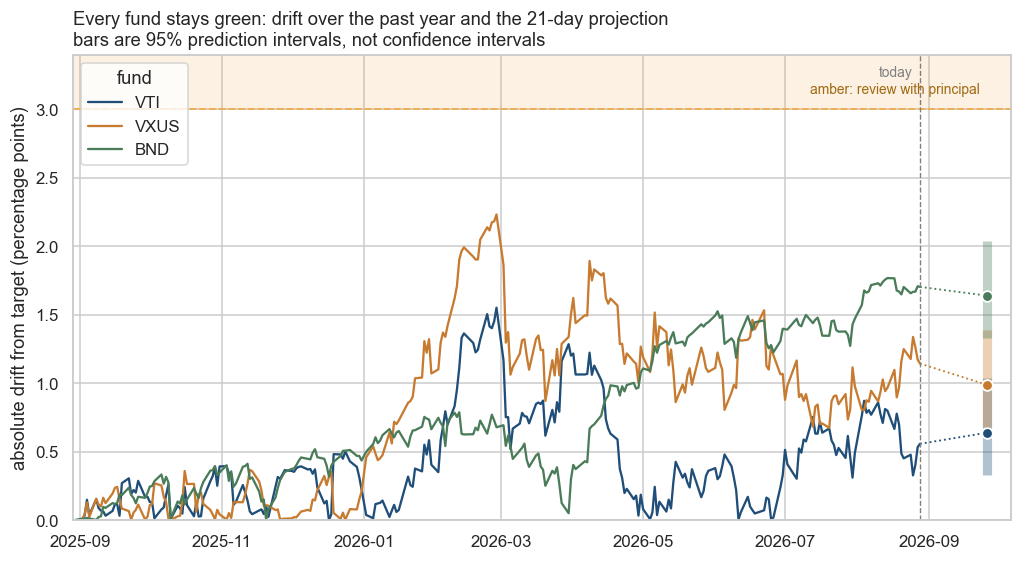

saved reports/images/report_bias_by_fund.png


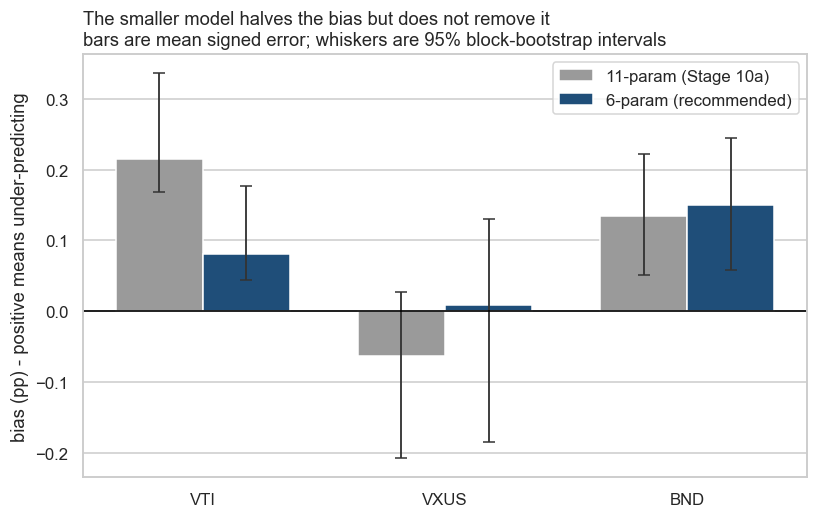

          bias  bias_lo  bias_hi  bias_excludes_zero
ticker                                              
BND     0.1503   0.0583   0.2445                True
VTI     0.0813   0.0446   0.1769                True
VXUS    0.0091  -0.1846   0.1308               False


In [7]:
drift_hist = matrix[['date', 'ticker', 'abs_drift']].dropna()
last_date = drift_hist['date'].max()
fcst_date = last_date + pd.Timedelta(days=int(HORIZON * 7 / 5))

fig, ax = plt.subplots(figsize=(11, 5.5))
ymax = max(3.4, float(fcst['hi'].max()) + 0.6)
ax.set_ylim(0, ymax)
ax.set_xlim(drift_hist['date'].min(), fcst_date + pd.Timedelta(days=10))
ax.axhspan(AMBER_PP, ymax, color='#f0ad4e', alpha=0.16)
ax.axhline(AMBER_PP, color='#f0ad4e', lw=1.2, ls='--')
ax.text(fcst_date, AMBER_PP + 0.09, 'amber: review with principal  ',
        color='#a06a12', fontsize=9, va='bottom', ha='right')

for t in ORDER:
    s = drift_hist[drift_hist['ticker'] == t]
    ax.plot(s['date'], s['abs_drift'], color=FUND_COLOR[t], lw=1.5, label=t)
    row = fcst[fcst['ticker'] == t].iloc[0]
    ax.plot([last_date, fcst_date], [s['abs_drift'].iloc[-1], row['point']],
            color=FUND_COLOR[t], lw=1.2, ls=':')
    ax.vlines(fcst_date, row['lo'], row['hi'], color=FUND_COLOR[t], lw=6, alpha=0.35)
    ax.plot(fcst_date, row['point'], 'o', color=FUND_COLOR[t], ms=7,
            markeredgecolor='white', markeredgewidth=1.2)

ax.axvline(last_date, color='grey', lw=0.9, ls='--')
ax.annotate('today', xy=(last_date, ymax), xytext=(-5, -7), textcoords='offset points',
            fontsize=9, color='grey', ha='right', va='top', annotation_clip=False)
ax.set_title('Every fund stays green: drift over the past year and the 21-day projection\n'
             'bars are 95% prediction intervals, not confidence intervals', loc='left')
ax.set_xlabel(''); ax.set_ylabel('absolute drift from target (percentage points)')
ax.legend(title='fund', loc='upper left', frameon=True)
savefig(fig, 'report_drift_and_forecast.png')
plt.show()

fig, ax = plt.subplots(figsize=(8.5, 5))
sub11 = ev.subgroup_report(test, r11, group='ticker', block=10, n_boot=N_BOOT, seed=SEED, level=LEVEL)
sub5 = ev.subgroup_report(test, r5, group='ticker', block=10, n_boot=N_BOOT, seed=SEED, level=LEVEL)
x = np.arange(len(ORDER)); w = 0.36
for off, sub, lab, col in [(-w/2, sub11, '11-param (Stage 10a)', '#9a9a9a'),
                           (w/2, sub5, '6-param (recommended)', '#1f4e79')]:
    v = [sub.loc[t, 'bias'] for t in ORDER]
    lo = [sub.loc[t, 'bias'] - sub.loc[t, 'bias_lo'] for t in ORDER]
    hi = [sub.loc[t, 'bias_hi'] - sub.loc[t, 'bias'] for t in ORDER]
    ax.bar(x + off, v, w, label=lab, color=col, edgecolor='white')
    ax.errorbar(x + off, v, yerr=[lo, hi], fmt='none', ecolor='#333333', capsize=4, lw=1.2)
ax.axhline(0, color='black', lw=1.1)
ax.set_xticks(x); ax.set_xticklabels(ORDER)
ax.set_title('The smaller model halves the bias but does not remove it\n'
             'bars are mean signed error; whiskers are 95% block-bootstrap intervals', loc='left')
ax.set_ylabel('bias (pp) - positive means under-predicting')
ax.legend(frameon=True); ax.grid(axis='x', visible=False)
savefig(fig, 'report_bias_by_fund.png')
plt.show()

sub5.to_csv(PROC / 'report_subgroups_6param.csv')
print(sub5[['bias', 'bias_lo', 'bias_hi', 'bias_excludes_zero']].to_string())

## 5. The two artifacts

The principal is deciding whether to trust the model, which needs the caveats. Dana is
deciding whether to raise a fund this month, which needs a number and a colour. A caveat
Dana cannot act on hides the number she can, so these are two files and not one file with
a summary at the top.

In [8]:
monitor = rp.monitor_table(fcst, latest['abs_drift'].to_numpy(),
                           latest['ticker'].to_numpy(), per_fund_bias=bias5)
rp.export_for_excel(monitor, REPORTS / 'drift_monitor_current.csv')
print(monitor.to_string(index=False))
print()

log = rp.DecisionLog()
log.add(stage='06', step='Missing closes',
        decision='Forward fill, and flag every filled row',
        rationale='A drift series with holes is unreadable; a silent fill is untraceable.',
        alternatives='Drop incomplete days; interpolate',
        risk='A long vendor outage would be filled invisibly if the flag is not watched.',
        impact='close_was_filled is currently constant, so untested in production.')
log.add(stage='07', step='Threshold unit',
        decision='Percentage points, with the relative unit kept as a scenario',
        rationale='The principal reads pp. Stage 12 confirmed the model is indifferent: '
                  '25.8% improvement over persistence in pp against 25.6% relative.',
        alternatives='Share of each fund target',
        risk='BND is 10% of the portfolio, so 1pp is a tenth of its target and a sixtieth '
             'of VTI. The units are not comparable to a reader who forgets that.',
        impact='Question closed on modelling grounds; the principal decides operationally.')
log.add(stage='10a', step='Split',
        decision='Chronological on dates, not rows and not random',
        rationale='A random split leaks the future through the 21-day overlap.',
        alternatives='Random split; TimeSeriesSplit only',
        risk='One split, one cut date. The score depends on where the cut falls.',
        impact='Scored 0.692 against 0.501 random, which contradicted what Stages 08 and '
               '09 predicted; both docs were amended.')
log.add(stage='12', step='Model choice',
        decision='Publish the 6-parameter model, not the 11-parameter one',
        rationale='Lower MAE (0.176 vs 0.192) and roughly half the VTI bias, on a target '
                  'carrying about 24 independent observations.',
        alternatives='11-param pooled; slope x fund interaction; separate model per fund',
        risk='Four candidates on one split; the ranking could reorder on a longer window.',
        impact='Moves BND 95% upper bound from 2.14pp to 2.04pp.')
log.add(stage='12', step='Bias handling',
        decision='Publish a measured offset beside the raw forecast, do not re-specify',
        rationale='In-sample per-fund bias is zero by construction, so the test bias is '
                  'out-of-sample regime drift no per-fund term fitted here can see.',
        alternatives='Per-fund interactions (rank deficient); separate models (worse)',
        risk='The offset is an observation from one window and may not persist.',
        impact='Moves BND 95% upper bound from 2.04pp to 1.89pp.')
log.add(stage='12', step='Interval published',
        decision='Prediction interval, not confidence interval',
        rationale='Dana reads one fund on one day, which is the prediction question.',
        alternatives='Confidence interval, half-width 0.034pp',
        risk='The wider band may read as the model being useless; the report names the '
             'persistence comparison to prevent that.',
        impact='11x wider than the CI and the only honest choice for this reader.')
print(f'decision log: {len(log.to_df())} entries -> {log.save(REPORTS / "decision_log.json")}')

fund  drift_today_pp  projected_21d_pp  lower_95_pp  upper_95_pp  projected_adjusted_pp band_today band_projected worst_case_band    action
 VTI          0.5596            0.6415       0.3328       1.0418                 0.5602      green          green           green no action
VXUS          1.1453            0.9891       0.6804       1.3894                 0.9800      green          green           green no action
 BND          1.7049            1.6406       1.3319       2.0409                 1.4902      green          green           green no action

decision log: 6 entries -> reports/decision_log.json


In [9]:
persistence_mae = float(np.mean(np.abs(test[TARGET].to_numpy() - test['abs_drift'].to_numpy())))
improvement = 100 * (1 - ev.mae(r5) / persistence_mae)
spec_swing = abs(float(tornado.loc[tornado['assumption'].str.startswith('Model'), 'high'].iloc[0])
                 - baseline_upper)

report = f'''# Portfolio Drift Monitor - findings for the firm principal

**Prepared:** Stage 12, FRE 5040. **Data through:** {last_date.date()}.
**Model:** 6-parameter chronological regression on a {HORIZON}-trading-day horizon.
**Companion artifact for client service:** `drift_monitor_current.csv`.

## Headline

**No fund needs attention this month, and that conclusion survives every assumption
tested.** The widest 95% upper bound any scenario produces is {tornado['high'].max():.2f}pp
against an amber line of {AMBER_PP:.0f}pp.

| Fund | drift today | projected {HORIZON} days | 95% interval | bias-adjusted | band |
|---|---|---|---|---|---|
'''
for _, r in monitor.iterrows():
    report += (f"| {r['fund']} | {r['drift_today_pp']:.2f}pp | {r['projected_21d_pp']:.2f}pp "
               f"| [{r['lower_95_pp']:.2f}, {r['upper_95_pp']:.2f}] "
               f"| {r['projected_adjusted_pp']:.2f}pp | {r['band_projected']} |\n")

report += f'''
![drift and forecast](images/report_drift_and_forecast.png)

## What changed since Stage 11

Stage 11 asked Stage 12 to correct a per-fund bias of {sub11.loc['VTI', 'bias']:.3f}pp for
VTI and {sub11.loc['BND', 'bias']:.3f}pp for BND using per-fund interactions. **That
correction is not available, and the reason is worth the principal's attention because it
changes where the remaining risk sits.**

- **The interaction was already in the model.** `abs_drift_rel` is `abs_drift` divided by
  the target weight, which makes it that interaction under a different name. Adding it
  explicitly gives a singular design matrix; a per-fund model cannot hold both columns.
- **The bias is not in the training window at all.** In-sample per-fund bias is zero to
  machine precision, because the fund dummies force it. Nothing fitted on that window can
  see the out-of-sample bias.
- **The target moved.** Average {HORIZON}-day-ahead drift rose {regime_all:+.2f}pp between
  the two windows, and BND's rose {shift.loc['BND', 'shift']:+.2f}pp.
- **More model makes it worse.** Separate per-fund models spend 15 parameters against
  about 24 independent observations, score MAE
  {sweep.loc['separate model per fund', 'mae']:.3f} against
  {sweep.loc['pooled 6-param (5 features)', 'mae']:.3f}, and leave all three funds biased.

So the monitor publishes the **smaller** model with a **measured offset** beside the raw
number, and labels the offset as an observation rather than a parameter.

![bias by fund](images/report_bias_by_fund.png)

## Which assumption to argue about

![tornado](images/report_tornado.png)

| assumption | BND 95% upper bound | change |
|---|---|---|
'''
for _, r in sens.iterrows():
    report += f"| {r['scenario']} | {r['bnd_upper_95_pp']:.2f}pp | {r['delta']:+.2f}pp |\n"

report += f'''
**The alternate scenario is regime.** Everything above assumes the next month resembles
the last twelve. If it instead resembles the *training* window, drift was
{abs(regime_all):.2f}pp lower on average and BND's upper bound falls from
{baseline_upper:.2f}pp to {baseline_upper - regime_all:.2f}pp.

That assumption swings the answer {abs(regime_all) / spec_swing:.1f} times further than the
model specification and {abs(regime_all) / abs(tornado['swing'].min()):.0f} times further
than the choice between a Gaussian and an empirical interval. **The next unit of effort
belongs on the data window, not on the model.**

## Assumptions and risks, in plain language

| Assumption | If it is wrong |
|---|---|
| The next month behaves like the last twelve | The largest single error source, worth {abs(regime_all):.2f}pp on the headline |
| The measured bias offset carries forward | Worth {abs(bias5['BND']):.2f}pp. It is an observation from one window, not a fitted parameter |
| {test['date'].nunique()} test dates can describe their own uncertainty | Stage 11 showed they cannot at a {HORIZON}-day timescale. Every interval here is a **floor** |
| Errors come from one distribution | BND's residuals are the least well behaved, so BND's interval is the least trustworthy |
| Prices keep arriving without gaps | Stage 06 fills them and `close_was_filled` flags them; currently constant, so untested |

**Risks worth naming.** BND is simultaneously the fund closest to amber and the fund the
model is least right about, which is the worst of the three pairings. The data covers one
year and one regime, with no market stress in the window.

## Recommended next steps

1. **No rebalancing action this month.** No fund reaches amber under any assumption tested.
2. **Extend the data window before touching the model.** The sensitivity analysis says it
   is worth roughly three times more, and it is the only fix for the interval being a floor.
3. **Re-estimate if realized volatility leaves its recent band** (about 13% VTI, 17% VXUS,
   4% BND annualized).
4. **Report BND on its upper bound**, not its point estimate. It is the only fund whose
   interval comes within {AMBER_PP - float(monitor['upper_95_pp'].max()):.1f}pp of amber.

## Method, in one paragraph

Daily closes for VTI, VXUS and BND over a rolling one-year window are cleaned (Stage 06),
converted to drift against the 60/30/10 target and to features (Stage 09), then regressed
on {HORIZON}-trading-day-ahead absolute drift using a split that trains on the first 80% of
*dates* (Stage 10a). Intervals are built from the residual distribution rather than the
regression's own standard errors, which assume an independence this target does not have
(Stage 11). Against a persistence baseline the model improves mean absolute error by
**{improvement:.1f}%**. Full reasoning for each choice, including the alternatives rejected,
is in `decision_log.json`.
'''

(REPORTS / 'final_report.md').write_text(report, encoding='utf-8')
print(f'wrote reports/final_report.md ({len(report.splitlines())} lines)')

wrote reports/final_report.md (102 lines)


In [10]:
readme = f'''# reports/ - the stakeholder-facing layer

## Two readers, two artifacts

**The firm principal** decides whether this model is trusted enough to change how the
portfolio is watched. That decision needs the caveats: the effective sample size, the bias
that cannot be specified away, the interval being a floor rather than a bound.
`final_report.md` is written for that reader.

**Dana**, the client-service associate, decides whether to raise a fund with the principal
this month. She works in Excel and does not run scripts. That decision needs a number, a
band and an action. `drift_monitor_current.csv` opens by double click and contains no model
vocabulary: no MAE, no residual, no interval half-width, just today's drift, the projection,
the worst case inside the published band, and what to do.

Splitting them is the point of this stage. A caveat Dana cannot act on hides the number she
can, and a number without caveats is not something the principal can sign off.

## Why a written report rather than a slide deck

The principal's question is "should I believe this", and the honest answer runs to several
paragraphs of assumption and caveat. A deck would force that into bullets, and the
compression is exactly where the meaning would go. A written report also survives being
re-read in three months by someone checking whether the numbers still hold, which is the
real review pattern for a monitor that runs continuously.

The deck-shaped need belongs to Dana, and a spreadsheet serves it better than slides do.

## Contents

| File | Reader | What it answers |
|---|---|---|
| `final_report.md` | firm principal | Should this model be trusted, and what would change the answer |
| `drift_monitor_current.csv` | Dana | Which funds need attention this month |
| `decision_log.json` | reviewer or successor | Why each choice was made, and what was rejected |
| `images/report_drift_and_forecast.png` | both | Is drift trending, and where does it go next |
| `images/report_tornado.png` | principal | Which assumption is worth arguing about |
| `images/report_bias_by_fund.png` | principal | How much of Stage 11's bias the smaller model removes |

Stage 08 to 11 diagnostic images also live in `images/` under their own prefixes
(`eda_`, `model_`, `ts_`, `eval_`). Those are working figures for the analyst, not
stakeholder artifacts, and the `report_` prefix marks the difference.

## Reproducing

`notebooks/delivery.ipynb`, run top to bottom, regenerates every file listed above.
`notebooks/project_pipeline.ipynb` runs the same section as part of the full chain.

The pipeline pulls a **rolling one-year window**, so a run months from now will move these
figures. The ones quoted in `final_report.md` are from **{last_date.date()}**, and that
date is printed in the report itself so a stale copy is detectable.
'''

(REPORTS / 'README.md').write_text(readme, encoding='utf-8')
print(f'wrote reports/README.md ({len(readme.splitlines())} lines)')
print()
for p in sorted(REPORTS.glob('*')) + sorted(IMG.glob('report_*')):
    print(f'  {str(p):<48} {p.stat().st_size if p.is_file() else 0:>8} bytes')

wrote reports/README.md (51 lines)

  reports/README.md                                    2815 bytes
  reports/dashboard_sketch.png                       365920 bytes
  reports/decision_log.json                            3262 bytes
  reports/drift_monitor_current.csv                     332 bytes
  reports/final_report.md                              5215 bytes
  reports/images                                          0 bytes
  reports/monitoring_status_20260830-1204.csv           686 bytes
  reports/images/report_bias_by_fund.png             123620 bytes
  reports/images/report_drift_and_forecast.png       395831 bytes
  reports/images/report_tornado.png                  194553 bytes


## 6. Check the prose against the numbers

Every figure quoted in `final_report.md` and in this notebook's markdown, recomputed and
compared. The pipeline pulls a rolling window, so the prose is written once and the data
moves underneath it. This is the cell that catches that.

In [11]:
checks = {
    'regime shift is +0.31pp': abs(regime_all - 0.31) < 0.005,
    'regime is the largest swing': tornado.iloc[0]['assumption'].startswith('Regime'),
    'interval shape is the smallest swing': tornado.iloc[-1]['assumption'].startswith('Interval'),
    'in-sample bias is zero': abs(r11_train.mean()) < 1e-9,
    'abs_drift_rel is exactly abs_drift / weight':
        float((data['abs_drift_rel'] - recon).abs().max()) < 1e-12,
    '6-param MAE is 0.176': abs(sweep.loc['pooled 6-param (5 features)', 'mae'] - 0.176) < 0.001,
    'separate models MAE is 0.216': abs(sweep.loc['separate model per fund', 'mae'] - 0.216) < 0.001,
    'improvement over persistence is 25.8%': abs(improvement - 25.8) < 0.15,
    'widest upper bound is 2.14pp': abs(tornado['high'].max() - 2.14) < 0.005,
    'no fund reaches amber': bool((monitor['worst_case_band'] == 'green').all()),
    'VTI bias falls 0.215 -> 0.081':
        abs(sub11.loc['VTI', 'bias'] - 0.215) < 0.002 and abs(sub5.loc['VTI', 'bias'] - 0.081) < 0.002,
    'report names the correct data date': f'{last_date.date()}' in report,
}
for f in ['final_report.md', 'README.md', 'drift_monitor_current.csv', 'decision_log.json']:
    checks[f'reports/{f} exists'] = (REPORTS / f).exists()
for f in ['report_drift_and_forecast.png', 'report_tornado.png', 'report_bias_by_fund.png']:
    checks[f'images/{f} exists'] = (IMG / f).exists()

for k, v in checks.items():
    print(f"{'PASS' if v else 'FAIL'}  {k}")
print()
print('all checks passed' if all(checks.values())
      else 'SOMETHING FAILED - the prose and the data disagree, fix before committing')

PASS  regime shift is +0.31pp
PASS  regime is the largest swing
PASS  interval shape is the smallest swing
PASS  in-sample bias is zero
PASS  abs_drift_rel is exactly abs_drift / weight
PASS  6-param MAE is 0.176
PASS  separate models MAE is 0.216
PASS  improvement over persistence is 25.8%
PASS  widest upper bound is 2.14pp
PASS  no fund reaches amber
PASS  VTI bias falls 0.215 -> 0.081
PASS  report names the correct data date
PASS  reports/final_report.md exists
PASS  reports/README.md exists
PASS  reports/drift_monitor_current.csv exists
PASS  reports/decision_log.json exists
PASS  images/report_drift_and_forecast.png exists
PASS  images/report_tornado.png exists
PASS  images/report_bias_by_fund.png exists

all checks passed


## What Stage 12 changed

**The project has a deliverable.** `reports/final_report.md` for the principal,
`reports/drift_monitor_current.csv` for Dana, and `reports/decision_log.json` for whoever
inherits this.

**Stage 11's handoff instruction was wrong, and it is now corrected in place.** The
per-fund bias cannot be modelled away: the interaction already exists under another name,
the bias is not present in the training window at all, and every attempt to add flexibility
made both the accuracy and the bias worse. `docs/evaluation.md` carries an amendment.

**The project's priorities are reordered.** Regime moves the headline three times further
than the model specification and twenty times further than the interval shape. Eleven
stages of modelling refinement have been chasing the third-largest lever, and the honest
recommendation to the principal is to lengthen the data window before touching the model
again.

**Nothing about the data, the thresholds or the features was changed.** Stage 12 packages;
it does not adjust.